In [11]:
from datetime import datetime
import numpy as np, pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path
import sys, os
import math
import matplotlib.pyplot as plt
from copy import deepcopy
import time

sys.path.append('../param_estimator')

from vbm_optimizer import VehicleBicycleModelParams, BicycleModelOptimizer, VehiclePlantModel


In [12]:
# setup initial VBM parameters
original_params = VehicleBicycleModelParams(
    4.718, 5.4562, 3.74, 0.15875, 0.17145, 0.04712
)

# Drive cycle parameters
sample_time_s = 0.02
driving_time_s = 60.0
drive_times_s = np.arange(0.0, driving_time_s, sample_time_s)

# speed drive cycle calculations
mean_speed_mps = 2.0
speed_amplitude_mps = 1.0
speed_freq_hz = 0.05
speeds_mps = speed_amplitude_mps * np.sin(2 * math.pi * speed_freq_hz * drive_times_s) + mean_speed_mps

# road wheel angle drive cycle calculations
mean_rwa_rad = 0.0
rwa_amplitude_rad = 0.2
rwa_freq_hz = 0.03
rwas_rad = rwa_amplitude_rad * np.sin(2 * math.pi * rwa_freq_hz * drive_times_s) + mean_rwa_rad


In [13]:
import itertools

def get_kus(param_set):
    return (param_set.lr_m * param_set.mass_kg) / (param_set.cf_Nprad * (param_set.lf_m + param_set.lr_m)) - (param_set.lf_m * param_set.mass_kg) / (param_set.cr_Nprad * (param_set.lf_m + param_set.lr_m))

# DOE Setup - sweep through all parameters under variation with breakpoints of [0.7, 0.85, 1.0, 1.15, 1.3]*original
multiples = [0.85, 0.875, 0.9, 0.925, 0.95, 0.975, 1.0, 1.025, 1.05, 1.075, 1.1, 1.125, 1.15]

lf = original_params.lf_m
lr = original_params.lr_m
cfs = [original_params.cf_Nprad * multiple for multiple in multiples]
crs = [original_params.cr_Nprad * multiple for multiple in multiples]
ms = [original_params.mass_kg * multiple for multiple in multiples]
izs = [original_params.izz_kgm2 * multiple for multiple in multiples]

# combinations = list(itertools.product(cfs, crs, ms, izs))
# combinations = list(itertools.product(cfs, crs, ms, izs))
combinations = list(itertools.product(cfs, crs))

# create a new parameter set for each combination
param_sets, kuss = [], []
for combo in combinations:
    new_vbm_params = VehicleBicycleModelParams(combo[0], combo[1], original_params.mass_kg, lf, lr, original_params.izz_kgm2)
    param_sets.append(new_vbm_params)
    kuss.append(get_kus(new_vbm_params))


In [14]:
FIG_SAVE_LOC = 'figures/doe/'

def get_description_strings(stats):
    filename_prefix = f'paramest_cf_{stats["params_actual"].cf_Nprad:.2f}_cr_{stats["params_actual"].cr_Nprad:.2f}_m_{stats["params_actual"].mass_kg:.2f}_iz_{stats["params_actual"].izz_kgm2:.2f}'
    # pretty_actual_string = f'$C_f$ = {stats["params_actual"].cf_Nprad:.2f} N/rad, $C_r$ = {stats["params_actual"].cr_Nprad:.2f} N/rad, $m$ = {stats["params_actual"].mass_kg:.2f} kg, $I_z$ = {stats["params_actual"].izz_kgm2:.2f} kgm^2'
    pretty_actual_string = f'$C_f$ = {stats["params_actual"].cf_Nprad:.2f} N/rad, $C_r$ = {stats["params_actual"].cr_Nprad:.2f} N/rad ($K_{{us}} = {get_kus(stats["params_actual"]):.2f}$)'
    # pretty_pred_string = f'$C_f$ = {stats["params_pred"].cf_Nprad:.2f} N/rad, $C_r$ = {stats["params_pred"].cr_Nprad:.2f} N/rad, $m$ = {stats["params_pred"].mass_kg:.2f} kg, $I_z$ = {stats["params_pred"].izz_kgm2:.2f} kgm^2'
    pretty_pred_string = f'ESTIMATE: $C_f$ = {stats["params_pred"].cf_Nprad:.2f} N/rad, $C_r$ = {stats["params_pred"].cr_Nprad:.2f} N/rad ($K_{{us}} = {get_kus(stats["params_pred"]):.2f}$)'
    return filename_prefix, pretty_actual_string, pretty_pred_string

def plot_paths(stats):
    
    fig, ax = plt.subplots(1)
    ax.plot(-stats['ys_init'], stats['xs_init'], '--', c='green', label='Initial Path')
    ax.plot(-stats['ys_actual'], stats['xs_actual'], c='red', label='Actual Path')
    ax.plot(-stats['ys_pred'], stats['xs_pred'], c='blue', label='Predicted Path')
    ax.legend()
    ax.set_xlabel('Lateral Distance (m)')
    ax.set_ylabel('Longitudinal Distance (m)')
    ax.grid()
    filename_prefix, pretty_string, pretty_pred_string = get_description_strings(stats)
    fig.suptitle(f'Parameter Estimation DOE Results - {pretty_string}')
    ax.set_title(pretty_pred_string)
    fig.set_size_inches(8, 8)
    fig.set_tight_layout(True)
    fig.savefig(FIG_SAVE_LOC + filename_prefix + '_paths.svg')
    plt.close(fig)
    
def plot_signals(stats):
    
    fig, ax = plt.subplots(4)
    ax[-1].set_xlabel('Time (s)')
    
    ax[0].plot(stats['times'], stats['ys_actual'], c='red', label='Actual Lateral Position')
    ax[0].plot(stats['times'], stats['ys_pred'], c='blue', label='Predicted Lateral Position')
    ax[0].set_ylabel('Position (m)')
    
    ax[1].plot(stats['times'], stats['thetas_actual'], c='red', label='Actual Heading')
    ax[1].plot(stats['times'], stats['thetas_pred'], c='blue', label='Predicted Heading')
    ax[1].set_ylabel('Heading (rad)')

    ax[2].plot(stats['times'], stats['yawrates_actual'], c='red', label='Actual Yaw Rate')
    ax[2].plot(stats['times'], stats['yawrates_pred'], c='blue', label='Predicted Yaw Rate')
    ax[2].set_ylabel('Yaw Rate (rad/s)')
    
    ax[3].plot(stats['times'], stats['ays_actual'], c='red', label='Actual Lateral Accel')
    ax[3].plot(stats['times'], stats['ays_pred'], c='blue', label='Predicted Lateral Accel')
    ax[3].set_ylabel('Lateral Accel (m/s^2)')
    
    for a in ax:
        a.legend()
        a.grid()
    
    filename_prefix, pretty_string, pretty_pred_string = get_description_strings(stats)
    fig.suptitle(f'Parameter Estimation DOE Results - {pretty_string}')
    ax[0].set_title(pretty_pred_string)
    fig.set_size_inches(10, 8)
    fig.set_tight_layout(True)
    fig.savefig(FIG_SAVE_LOC + filename_prefix + '_graphs.svg')
    plt.close(fig)
    
def get_param_est_metrics(stats):
    metrics = {}
    metrics['cf_error'] = stats['params_actual'].cf_Nprad - stats['params_pred'].cf_Nprad
    metrics['cr_error'] = stats['params_actual'].cr_Nprad - stats['params_pred'].cr_Nprad
    metrics['mass_error'] = stats['params_actual'].mass_kg - stats['params_pred'].mass_kg
    metrics['iz_error'] = stats['params_actual'].izz_kgm2 - stats['params_pred'].izz_kgm2
    metrics['kus_error'] = get_kus(stats['params_actual']) - get_kus(stats['params_pred'])
    metrics['mean_path_dev'] = np.mean(np.sqrt(np.square(stats['xs_actual'] - stats['xs_pred']) + np.square(stats['ys_actual'] - stats['ys_pred'])))
    metrics['rmse_heading'] = np.sqrt(np.mean(np.square(stats['thetas_actual'] - stats['thetas_pred'])))
    metrics['rmse_yawrate'] = np.sqrt(np.mean(np.square(stats['yawrates_actual'] - stats['yawrates_pred'])))
    metrics['rmse_ay'] = np.sqrt(np.mean(np.square(stats['ays_actual'] - stats['ays_pred'])))

def run_param_est_scenario(params):
    
    initial_plant = VehiclePlantModel(deepcopy(original_params), major_sample_time_s=sample_time_s)
    initial_plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_init = np.array(initial_plant.poses)[:,0]
    ys_init = np.array(initial_plant.poses)[:,1]
    
    initial_time = time.process_time()
    
    plant = VehiclePlantModel(deepcopy(params), major_sample_time_s=sample_time_s)
    plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_actual = np.array(plant.poses)[:,0]
    ys_actual = np.array(plant.poses)[:,1]
    thetas_actual = np.array(plant.poses)[:,2]
    yawrates_actual = np.array(plant.states)[:,1]
    ays_actual = np.array(plant.ays)
    
    vbm_optimizer = BicycleModelOptimizer(deepcopy(original_params), optimize_mass=False, optimize_iz=False)
    costs = vbm_optimizer.optimize_vbm_params(drive_times_s, rwas_rad, speeds_mps, xs_actual, ys_actual, yawrates_actual, thetas_actual, ays_actual)
    
    optimized_plant = VehiclePlantModel(vbm_optimizer.vbm_params, major_sample_time_s=sample_time_s)
    optimized_plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_pred = np.array(optimized_plant.poses)[:,0]
    ys_pred = np.array(optimized_plant.poses)[:,1]
    thetas_pred = np.array(optimized_plant.poses)[:,2]
    yawrates_pred = np.array(optimized_plant.states)[:,1]
    ays_pred = np.array(optimized_plant.ays)
    
    final_time = time.process_time()
    
    # plot_paths(xs_actual, ys_actual, xs_pred, ys_pred)
    
    stats = {'params_pred': vbm_optimizer.vbm_params,
            'params_actual': params,
            'times': drive_times_s,
            'xs_actual': xs_actual,
            'ys_actual': ys_actual,
            'thetas_actual': thetas_actual,
            'yawrates_actual': yawrates_actual,
            'ays_actual': ays_actual,
            'xs_pred': xs_pred,
            'ys_pred': ys_pred,
            'thetas_pred': thetas_pred,
            'yawrates_pred': yawrates_pred,
            'ays_pred': ays_pred,
            'xs_init': xs_init,
            'ys_init': ys_init,
            'costs': costs,
            'solve_time': (final_time - initial_time)}
    
    metrics = get_param_est_metrics(stats)
    plot_paths(stats)
    plot_signals(stats)
    
    return {
        'stats': stats,
        'metrics': metrics
    }


In [15]:
param_set = param_sets[8]

metadata = run_param_est_scenario(deepcopy(param_set))

optimized_params = metadata['stats']['params_pred']
print('=============================')
print(f'initial params    : Cf = {original_params.cf_Nprad:.3f}, Cr = {original_params.cr_Nprad:.3f}, m = {original_params.mass_kg:.3f}, iz = {original_params.izz_kgm2:.3f}')
print(f'actual params     : Cf = {param_set.cf_Nprad:.3f}, Cr = {param_set.cr_Nprad:.3f}, m = {param_set.mass_kg:.3f}, iz = {param_set.izz_kgm2:.3f}')
print(f'optimized params  : Cf = {optimized_params.cf_Nprad:.3f}, Cr = {optimized_params.cr_Nprad:.3f}, m = {optimized_params.mass_kg:.3f}, iz = {optimized_params.izz_kgm2:.3f}')

# cfs, crs, costs, cost_terms = metadata['stats']['costs']['cfs'], metadata['stats']['costs']['crs'],  metadata['stats']['costs']['costs'],  metadata['stats']['costs']['cost_terms']

# # norm_costs = [min(c / np.median(np.array(costs)), 1.0) for c in costs]
# # sc = plt.scatter(cfs, crs, c=norm_costs, s=500, marker='s')
# # plt.colorbar(sc)
# norm_costs = [min(c / np.median(np.array(costs) / 3), 1.0) for c in costs]
# sc = plt.scatter(cfs, crs, c=norm_costs, s=13, marker='s')
# plt.colorbar(sc)

# kus = get_kus(param_set)


best params: VehicleBicycleModelParams(cf_Nprad=4.17760009090569, cr_Nprad=5.4507465468987375, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
initial params    : Cf = 4.718, Cr = 5.456, m = 3.740, iz = 0.047
actual params     : Cf = 4.010, Cr = 5.729, m = 3.740, iz = 0.047
optimized params  : Cf = 4.178, Cr = 5.451, m = 3.740, iz = 0.047


In [16]:
# mse_paths = np.array([c[0] for c in cost_terms])
# mse_thetas = np.array([c[1] for c in cost_terms])
# mse_omegas = np.array([c[2] for c in cost_terms])
# mse_ays = np.array([c[3] for c in cost_terms])

# # costs = (300000*mse_ays + 400*mse_paths + mse_thetas + 6*mse_thetas)
# costs = (mse_thetas)

# norm_costs = [min(c / np.median(np.array(costs)) / .5, 1.0) for c in costs]
# sc = plt.scatter(cfs, crs, c=norm_costs, s=13, marker='s')
# sc = plt.scatter([param_set.cf_Nprad], [param_set.cr_Nprad], c='black', s=100, marker='*')
# plt.colorbar(sc)

# kus = get_kus(param_set)


In [17]:
original_params


VehicleBicycleModelParams(cf_Nprad=4.718, cr_Nprad=5.4562, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)

In [ ]:
import multiprocessing as mp
import pickle, asyncio

results = {}
run_doe = True

if run_doe:
    # Determine your system's core count
    cores = mp.cpu_count() 

    with mp.Pool(processes=cores) as pool:
        results = pool.map(run_param_est_scenario, param_sets)
            
    # save dataframe for future analysis
    with open(f'data/results.pkl', 'wb') as f:
        pickle.dump(results, f)


best params: VehicleBicycleModelParams(cf_Nprad=4.162492667420349, cr_Nprad=5.453083776573387, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.204647177906641, cr_Nprad=5.44931346740351, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.608050104895939, cr_Nprad=5.359432605800861, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.16303049166582, cr_Nprad=5.452393972339712, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.128465077887503, cr_Nprad=5.4567532911697905, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.20233981732974, cr_Nprad=5.450277284431509, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.213029095874578, cr_Np

In [19]:
def brute_force_sweep(param_set):
    
    scalar_options_cf = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3]
    scalar_options_cr = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3]
    
    k_cf_results, k_cr_results, costs = [], [], []
    
    plant = VehiclePlantModel(param_set, major_sample_time_s=sample_time_s, sample_time_s=sample_time_s)
    plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_actual = np.array(plant.poses)[:,0]
    ys_actual = np.array(plant.poses)[:,1]
    thetas_actual = np.array(plant.poses)[:,2]
    yawrates_actual = np.array(plant.states)[:,1]
    
    for k_cf in scalar_options_cf:
        for k_cr in scalar_options_cr:
            vbmo = BicycleModelOptimizer(deepcopy(original_params), optimize_mass=False, optimize_iz=False)
            vbmo.times_s = drive_times_s
            vbmo.rwas_rad = rwas_rad
            vbmo.speeds_mps = speeds_mps
            vbmo.xs_actual = xs_actual
            vbmo.ys_actual = ys_actual
            vbmo.thetas_actual = thetas_actual
            vbmo.yrs_actual = yawrates_actual
            vbmo.w_path, vbmo.w_final_drift, vbmo.w_theta, vbmo.w_yawrate = 0.00, 0.0, 0.0, 1.0
            cost = vbmo.simulate_and_get_cost([k_cf, k_cr])
            
            k_cf_results.append(k_cf)
            k_cr_results.append(k_cr)
            costs.append(cost)
            print(k_cf, k_cr, cost)
            
    return {
        'k_cfs': k_cf_results,
        'k_crs': k_cr_results,
        'costs': costs,
    }


In [20]:
k_cf_real, k_cr_real = 0.9, 1.1

real_params = VehicleBicycleModelParams(k_cf_real*original_params.cf_Nprad, k_cr_real*original_params.cr_Nprad, original_params.mass_kg, lf, lr, original_params.izz_kgm2)
sweep_results = brute_force_sweep(real_params)


AttributeError: 'BicycleModelOptimizer' object has no attribute 'ays_actual'

In [ ]:
# plant = VehiclePlantModel(real_params, major_sample_time_s=sample_time_s, sample_time_s=sample_time_s)
# plant.simulate_over_horizon(rwas_rad, speeds_mps)

# xs_actual = np.array(plant.poses)[:,0]
# ys_actual = np.array(plant.poses)[:,1]
# thetas_actual = np.array(plant.poses)[:,2]
# yawrates_actual = np.array(plant.states)[:,1]

# vbmo = BicycleModelOptimizer(deepcopy(original_params), optimize_mass=False, optimize_iz=False)
# vbmo.times_s = drive_times_s
# vbmo.rwas_rad = rwas_rad
# vbmo.speeds_mps = speeds_mps
# vbmo.xs_actual = xs_actual
# vbmo.ys_actual = ys_actual
# vbmo.thetas_actual = thetas_actual
# vbmo.yrs_actual = yawrates_actual
# vbmo.w_path, vbmo.w_final_drift, vbmo.w_theta, vbmo.w_yawrate = 1.00, 0.0, 0.0, 1.0
# cost = vbmo.simulate_and_get_cost([0.8, 0.95])

# print(cost)

# xs_pred, ys_pred, yaws_pred, yaw_rates_pred, ay_pred = vbmo.simulate_vbm(vbmo.times_s, vbmo.rwas_rad, vbmo.speeds_mps)

# mse_path = np.mean(np.square(ys_actual - ys_pred))
# print(np.mean(np.square(ys_actual.flatten() - ys_pred.flatten())))
# mse_theta = np.sqrt(np.mean(np.square(thetas_actual - yaws_pred)))
# mse_yawrate = np.sqrt(np.mean(np.square(yawrates_actual - yaw_rates_pred)))
# print(mse_path, mse_theta, mse_yawrate)

# fig, ax = plt.subplots(1)
# ax.plot(-ys_actual, xs_actual, c='red', label='Actual Path')
# ax.plot(-ys_pred, xs_pred, c='blue', label='Predicted Path')
# ax.legend()
# ax.set_xlabel('Lateral Distance (m)')
# ax.set_ylabel('Longitudinal Distance (m)')
# ax.grid()
# # filename_prefix, pretty_string = get_description_strings(stats)
# # fig.suptitle('Parameter Estimation DOE Results')
# # ax.set_title(pretty_string)
# fig.set_size_inches(8, 8)
# fig.set_tight_layout(True)


In [ ]:
costs = np.array(sweep_results['costs'])
# norm_costs = [min(c / 100.0) for c in list(costs)]
norm_costs = [min(c / 10000.0, 1.0) for c in costs]
sc = plt.scatter(sweep_results['k_cfs'], sweep_results['k_crs'], c=norm_costs, s=500, marker='s')
plt.colorbar(sc)
# print(costs)


/tmp/ipykernel_279715/2205920620.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  costs = np.array(sweep_results['costs'])


TypeError: unsupported operand type(s) for /: 'list' and 'float'

In [ ]:
def get_kus(param_set):
    return (param_set.lr_m * param_set.mass_kg) / (param_set.cf_Nprad * (param_set.lf_m + param_set.lr_m)) - (param_set.lf_m * param_set.mass_kg) / (param_set.cr_Nprad * (param_set.lf_m + param_set.lr_m))

def get_cf_from_cr_and_kus(cr, kus, lf, lr, m):
    return ((1 / (kus + (lf*m)/(cr*(lf+lr))))*lr*m)/(lf + lr)

def search_along_kus_line(param_set):
    
    kus = get_kus(param_set)
    print('kus', kus)
    scalar_options_cr = np.arange(0.7, 1.3, 0.01)
    scalar_options_cf = [get_cf_from_cr_and_kus(cr*original_params.cr_Nprad, kus, original_params.lf_m, original_params.lr_m, original_params.mass_kg)/original_params.cf_Nprad for cr in scalar_options_cr]
    
    k_cf_results, k_cr_results, costs = [], [], []
    
    plant = VehiclePlantModel(param_set, major_sample_time_s=sample_time_s, sample_time_s=sample_time_s)
    plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_actual = np.array(plant.poses)[:,0]
    ys_actual = np.array(plant.poses)[:,1]
    thetas_actual = np.array(plant.poses)[:,2]
    yawrates_actual = np.array(plant.states)[:,1]
    
    for idx, k_cf in enumerate(scalar_options_cf):
        vbmo = BicycleModelOptimizer(deepcopy(original_params), optimize_mass=False, optimize_iz=False)
        vbmo.times_s = drive_times_s
        vbmo.rwas_rad = rwas_rad
        vbmo.speeds_mps = speeds_mps
        vbmo.xs_actual = xs_actual
        vbmo.ys_actual = ys_actual
        vbmo.thetas_actual = thetas_actual
        vbmo.yrs_actual = yawrates_actual
        vbmo.w_path, vbmo.w_final_drift, vbmo.w_theta, vbmo.w_yawrate = 1000.00, 0.0, 10.0, 1.0
        cost = vbmo.simulate_and_get_cost([scalar_options_cf[idx], scalar_options_cr[idx]])
            
        k_cf_results.append(scalar_options_cf[idx])
        k_cr_results.append(scalar_options_cr[idx])
        costs.append(cost)
        print(scalar_options_cf[idx], scalar_options_cr[idx], cost)
            
    return {
        'k_cfs': k_cf_results,
        'k_crs': k_cr_results,
        'costs': costs,
    }


In [ ]:
get_cf_from_cr_and_kus(6.00182, 0.157743373555, 0.15875, 0.17145, 3.74)


4.246199999997271

kus 0.15774337355470602
0.6548641245707291 0.7 279.3715334405631
0.6618463828534573 0.71 254.59459041111066
0.6687789300755119 0.72 231.8723484452561
0.6756622952399078 0.73 211.02980443908928
0.6824969998703033 0.74 191.90832993183403
0.6892835581427201 0.75 174.3639859211178
0.6960224770144869 0.76 158.26602678234946
0.7027142563504802 0.77 143.4955703865716
0.7093593890467221 0.78 129.9444144777392
0.7159583611514034 0.79 117.51398192788193
0.7225116519833953 0.8 106.11437969886454
0.7290197342483044 0.81 95.66355825356013
0.7354830741521381 0.8200000000000001 86.08655981380564
0.7419021315126312 0.8300000000000001 77.31484530170661
0.7482773598682938 0.8400000000000001 69.2856910464271
0.7546092065852312 0.8500000000000001 61.941647424529165
0.7608981129617918 0.8600000000000001 55.23005254559315
0.7671445143310932 0.8700000000000001 49.10259491832136
0.7733488401614759 0.8800000000000001 43.51491975028175
0.7795115141549347 0.8900000000000001 38.42627416124824
0.7856329543435722 0

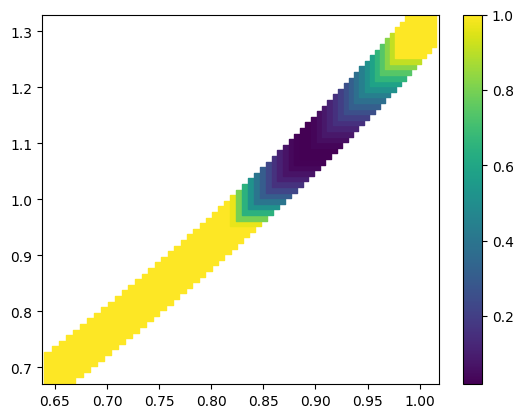

In [ ]:
k_cf_real, k_cr_real = 0.9, 1.1

real_params = VehicleBicycleModelParams(k_cf_real*original_params.cf_Nprad, k_cr_real*original_params.cr_Nprad, original_params.mass_kg, lf, lr, original_params.izz_kgm2)
sweep_results = search_along_kus_line(real_params)
costs = np.array(sweep_results['costs'])
# norm_costs = [min(c / 100.0) for c in list(costs)]
norm_costs = [min(c / np.median(costs), 1.0) for c in costs]
sc = plt.scatter(sweep_results['k_cfs'], sweep_results['k_crs'], c=norm_costs, s=500, marker='s')
plt.colorbar(sc)
# print(costs)


In [ ]:
def get_kus(param_set):
    return (param_set.lr_m * param_set.mass_kg) / (param_set.cf_Nprad * (param_set.lf_m + param_set.lr_m)) - (param_set.lf_m * param_set.mass_kg) / (param_set.cr_Nprad * (param_set.lf_m + param_set.lr_m))

def get_cf_from_cr_and_kus(cr, kus, lf, lr, m):
    return ((1 / (kus + (lf*m)/(cr*(lf+lr))))*lr*m)/(lf + lr)

def search_over_kus(param_set):
    
    kus_options = np.arange(0.0, 1.0, 0.01)
    scalar_options_cf = [get_cf_from_cr_and_kus(original_params.cr_Nprad, kus, original_params.lf_m, original_params.lr_m, original_params.mass_kg)/original_params.cf_Nprad for kus in kus_options]
    
    k_cf_results, k_cr_results, costs = [], [], []
    
    plant = VehiclePlantModel(param_set, major_sample_time_s=sample_time_s, sample_time_s=sample_time_s)
    plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_actual = np.array(plant.poses)[:,0]
    ys_actual = np.array(plant.poses)[:,1]
    thetas_actual = np.array(plant.poses)[:,2]
    yawrates_actual = np.array(plant.states)[:,1]
    
    for idx, k_cf in enumerate(scalar_options_cf):
        vbmo = BicycleModelOptimizer(deepcopy(original_params), optimize_mass=False, optimize_iz=False)
        vbmo.times_s = drive_times_s
        vbmo.rwas_rad = rwas_rad
        vbmo.speeds_mps = speeds_mps
        vbmo.xs_actual = xs_actual
        vbmo.ys_actual = ys_actual
        vbmo.thetas_actual = thetas_actual
        vbmo.yrs_actual = yawrates_actual
        vbmo.w_path, vbmo.w_final_drift, vbmo.w_theta, vbmo.w_yawrate = 0.00, 0.0, 0.0, 1.0
        cost = vbmo.simulate_and_get_cost([scalar_options_cf[idx], 1.0])
            
        k_cf_results.append(scalar_options_cf[idx])
        k_cr_results.append(1.0)
        costs.append(cost)
        print(scalar_options_cf[idx], 1.0, cost)
            
    return {
        'k_cfs': k_cf_results,
        'k_crs': k_cr_results,
        'costs': costs,
        'optimal_kus': kus_options[np.argmin(costs)]
    }


1.2489817719372616 1.0 5.5677097130916575
1.2121980562376797 1.0 3.3619525590209864
1.1775189883197934 1.0 2.1418957251319695
1.1447689601257978 1.0 1.41351019309428
1.1137913715003156 1.0 0.9537801827774057
1.0844461261686646 1.0 0.6515590933314159
1.056607513396753 1.0 0.4469281277204055
1.0301624077618765 1.0 0.3054793170634724
1.0050087326627855 1.0 0.2064107286103902
0.9810541435650663 1.0 0.13660076443273983
0.9582148951732895 1.0 0.08747391935517536
0.9364148632387193 1.0 0.05325570674951446
0.9155846969239527 1.0 0.02995756166291232
0.8956610818375654 1.0 0.01476369555222684
0.8765860972401103 1.0 0.00564843125714365
0.8583066536751873 1.0 0.0011304539283798134
0.8407739995256721 1.0 0.0001109653717208575
0.823943286836834 1.0 0.0017646899774584482
0.8077731882644527 1.0 0.005464998343292637
0.7922255582597232 1.0 0.010731543788190969
0.7772651326433686 1.0 0.01719305049294538
0.7628592615883996 1.0 0.024560482686493454
0.7489776717560166 1.0 0.032607442571710214
0.735592253937

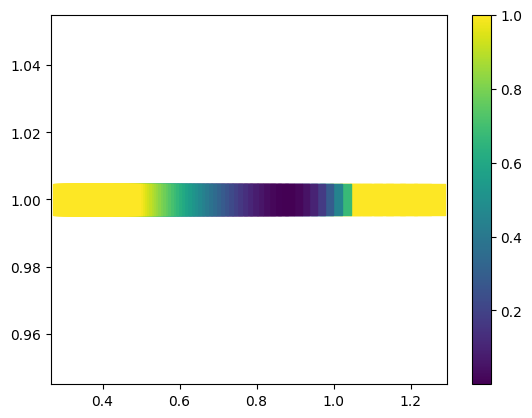

In [ ]:
k_cf_real, k_cr_real = 0.9, 1.1

real_params = VehicleBicycleModelParams(k_cf_real*original_params.cf_Nprad, k_cr_real*original_params.cr_Nprad, original_params.mass_kg, lf, lr, original_params.izz_kgm2)
sweep_results = search_over_kus(real_params)
costs = np.array(sweep_results['costs'])
# norm_costs = [min(c / 100.0) for c in list(costs)]
norm_costs = [min(c / np.median(costs[~np.isnan(costs)]), 1.0) for c in costs]
sc = plt.scatter(sweep_results['k_cfs'], sweep_results['k_crs'], c=norm_costs, s=500, marker='s')
plt.colorbar(sc)
# print(costs)


[ 0.          0.00075398  0.00150795 ... -0.1908981  -0.19067188
 -0.19044294]


KeyError: 'ys_actual'

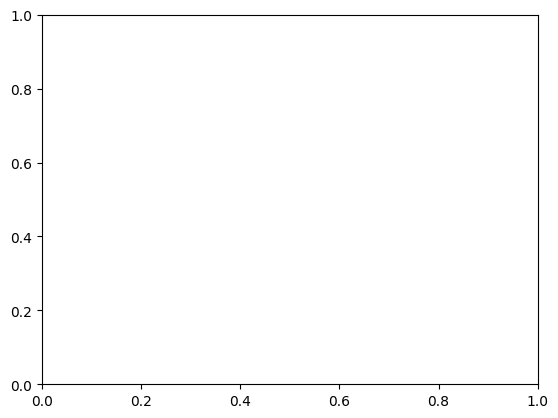

In [ ]:
params = VehicleBicycleModelParams(cf_Nprad=4.718, cr_Nprad=5.4562, mass_kg=0.15875, lf_m=0.17145, lr_m=3.74, izz_kgm2=0.04712)
original_params = VehicleBicycleModelParams(
    4.718, 5.4562, 3.74, 0.15875, 0.17145, 0.04712
)

plant = VehiclePlantModel(original_params, major_sample_time_s=sample_time_s, sample_time_s=sample_time_s)
# print(plant.params)
plant.simulate_over_horizon(rwas_rad, speeds_mps)
print(rwas_rad)

xs_actual = np.array(plant.poses)[:,0]
ys_actual = np.array(plant.poses)[:,1]
thetas_actual = np.array(plant.poses)[:,2]
yawrates_actual = np.array(plant.states)[:,1]

plot_paths({})

vbmo = BicycleModelOptimizer(deepcopy(params), optimize_mass=False, optimize_iz=False)
vbmo.times_s = drive_times_s
vbmo.rwas_rad = rwas_rad
vbmo.speeds_mps = speeds_mps
vbmo.xs_actual = xs_actual
vbmo.ys_actual = ys_actual
vbmo.thetas_actual = thetas_actual
vbmo.yrs_actual = yawrates_actual
cost = vbmo.simulate_and_get_cost_with_params(params)
